In [1]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
Notebook EnMAP - PIR Rio Tinto
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Data : EnMAP Image
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
HOSSEINI Arman, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualization</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Direct K-Means</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Pixel-by-Pixel AutoEncoder with K-Means on latent-space</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">2D Convolutional AutoEncoder with K-Means on latent space</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [1]:
import time
import os

import sys, random, re

import torch; import torch.nn as nn; import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset

import rasterio as rio; from rasterio.plot import reshape_as_image, reshape_as_raster
import numpy as np; import pandas as pd
from sklearn.preprocessing import StandardScaler; from sklearn.cluster import KMeans; from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
import matplotlib.pyplot as plt; import matplotlib.colors as colors; from matplotlib.colors import ListedColormap
from matplotlib import cm
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster; from kneed import KneeLocator
import xml.etree.ElementTree as ET
from tqdm import tqdm
from sklearn.manifold import TSNE
import seaborn as sns

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Visualization

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We start by applying masks to the EnMAP image and display them.

In [5]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read()).astype(np.float32) 

    arr_img = np.clip(arr_img, 0, 1)

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_2d = (mask_band > 0)
    mask_flat = mask_2d.ravel()

    X = image.reshape(l, -1).T
    pixels_interest = X[mask_flat]

    scaler = StandardScaler()
    scaled = scaler.fit_transform(pixels_interest)

    # On crée un tableau de zéros et on y injecte les pixels scalés
    # Le fond reste à 0.0 (la moyenne exacte de la végétation)
    X_scaled_flat = np.zeros_like(X)
    X_scaled_flat[mask_flat] = scaled

    # On remet l'image en 3D (m, n, l)
    X_scaled = X_scaled_flat.reshape(m, n, l)

    # --- 4. Préparation RGB pour affichage ---
    # On sélectionne les bandes R (2), G (1), B (0)
    rgb = X_scaled[:, :, [2, 1, 0]]

    # Calcul des min/max uniquement sur la zone d'intérêt pour un bon contraste
    # On utilise des percentiles ou un min/max localisé
    rgb_veg_only = rgb[mask_2d]
    min_val = np.nanmin(rgb_veg_only, axis=0)
    max_val = np.nanmax(rgb_veg_only, axis=0)
    
    # Normalisation 0-1 pour imshow
    rgb_norm = (rgb - min_val) / (max_val - min_val + 1e-8)
    
    # Forcer le fond en noir pur (Correction de la variable mask -> mask_band)
    fond_bool = (mask_band == 0)
    rgb_norm[fond_bool] = 0.0
    
    # Sécurité pour l'affichage
    rgb_norm = np.clip(rgb_norm, 0, 1)

    # --- 5. Affichage ---
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_norm)
    plt.title("Visualisation Standardisée (Végétation/Sol)")
    plt.axis('off')
    plt.show()

    return X_scaled, fond_bool

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the soil:

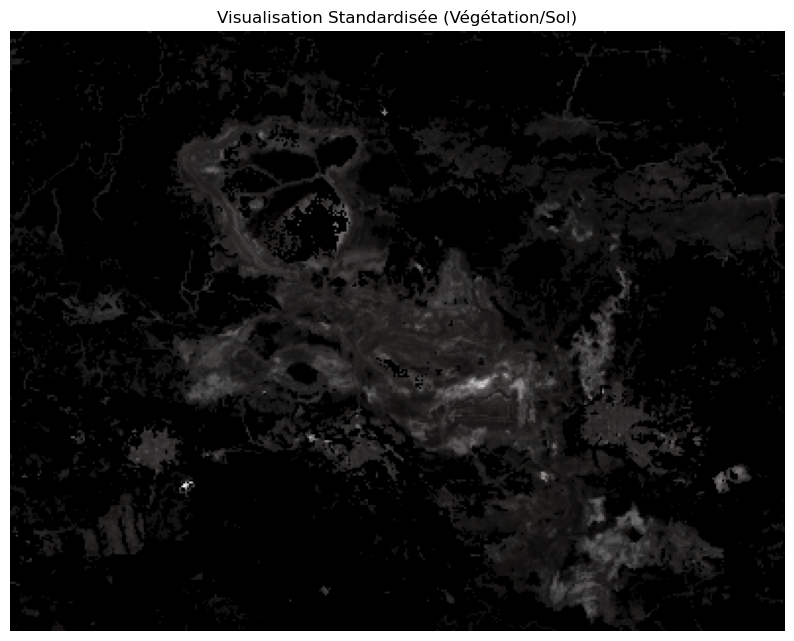

In [6]:
soil_only, fond_soil = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                       r"./INSA_cropped_2_EnMAP_20240508_mask_SOIL_SAVI_DSBI.tiff")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the vegetation:

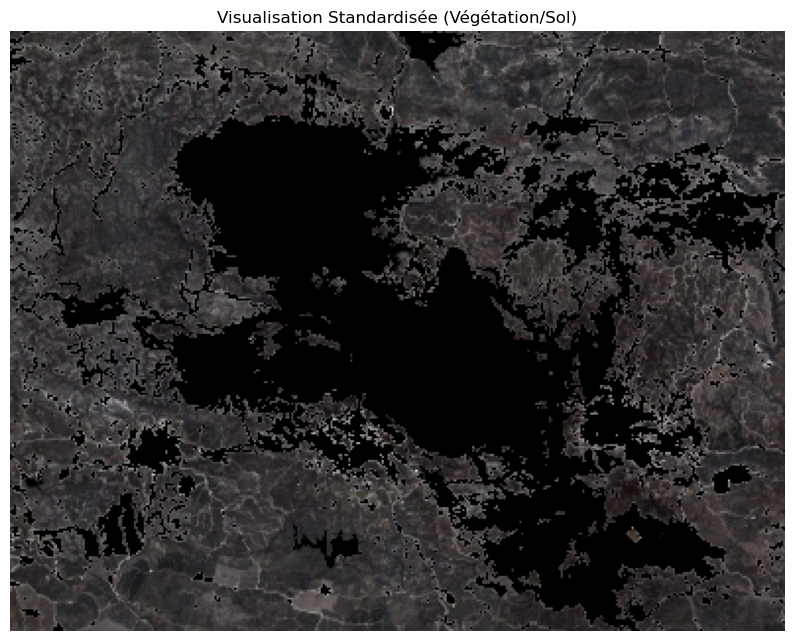

In [7]:
vegetation_only, fond_vegetation = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                             r"./INSA_cropped_2_EnMAP_20240508_mask_NDVI.tiff")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply the vegetation mask and set all external pixels to the mean of the scaled vegetation pixel values:

In [8]:
image_path = r'./INSA_cropped_2_EnMAP_20240508.tif'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = veg_pixels

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Direct K-Means 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We will use the knee criterion to guess the number of clusters we want for vegetation, soil and "other" separately:

<div id="21"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.1 Vegetation

In [9]:
def compute_optimal_k(X_scaled):

    inertias = []
    K_range = range(2, 20, 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        #print("Done")
    
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel('Inertia (Sum of distances)')
    plt.title('Knee criterion')
    plt.show()
    
    knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
    optimal_k = knee.knee
    
    print(f"optimal value: k = {optimal_k}")
    
    return optimal_k

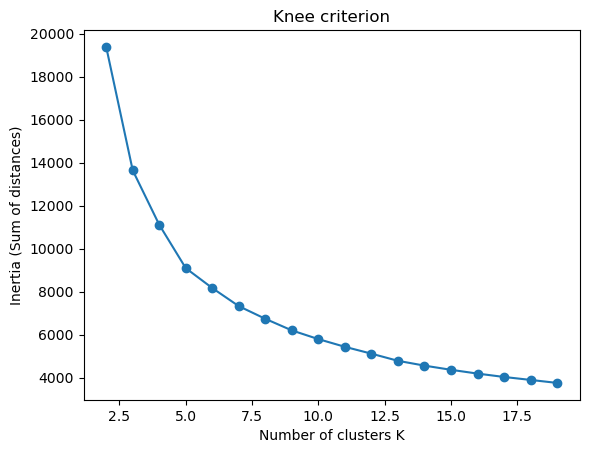

optimal value: k = 6


In [10]:
optimal_k_veg = compute_optimal_k(veg_pixels)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We use the function extract_wavelengths_from_auxxml to get the number of wavelengths and their values.

In [11]:
def extract_wavelengths_from_auxxml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    wavelengths = []

    # Pour chaque bande dans l'ordre
    for band in root.findall(".//PAMRasterBand"):
        desc = band.find("Description")
        if desc is not None and desc.text:
            match = re.search(r"\(([\d.]+)\s*Nanometers\)", desc.text)
            if match:
                wl = float(match.group(1))
                wavelengths.append(wl)

    return wavelengths

In [12]:
xml_file = r"./INSA_cropped_2_EnMAP_20240508.tif.aux.xml"
wavelengths = extract_wavelengths_from_auxxml(xml_file)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply K-Means and display the mean spectrum for each cluster. We also compute the Silhouette score.

In [13]:
def KMeans_mean_spectra(X_scaled, mask_1D, optimal_k, bands_number, wavelengths, max_samples=10000):
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans_final.fit_predict(X_scaled)
    
    n_samples = X_scaled.shape[0]
    
    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels
    
    sil_score = silhouette_score(X_sampled, labels_sampled)
    
    print(f"Silhouette (sampled) for k = {optimal_k} : {sil_score:.3f}")
    
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = wavelengths
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()
    return labels

Silhouette (sampled) for k = 6 : 0.304


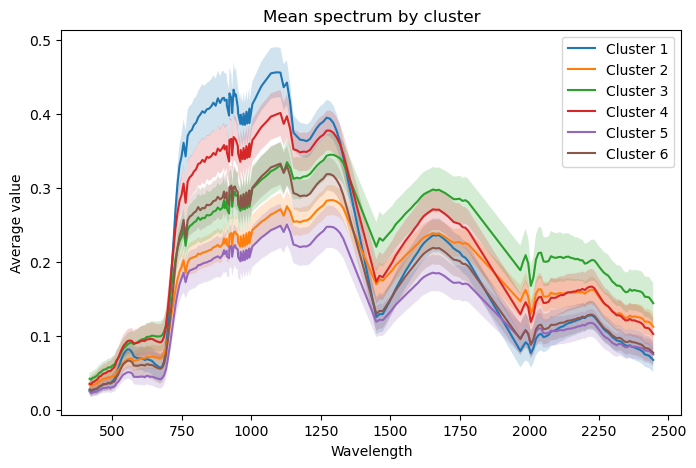

In [14]:
labels_veg = KMeans_mean_spectra(veg_pixels, veg_mask_1d, optimal_k_veg, l, wavelengths)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Then, We can display the map with clustered vegetation. Masked pixels are displayed in black.

In [15]:
def display_clusters(mask_2D, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)
    cluster_map[mask_2D] = labels + 1  # 0 = fond, clusters à partir de 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

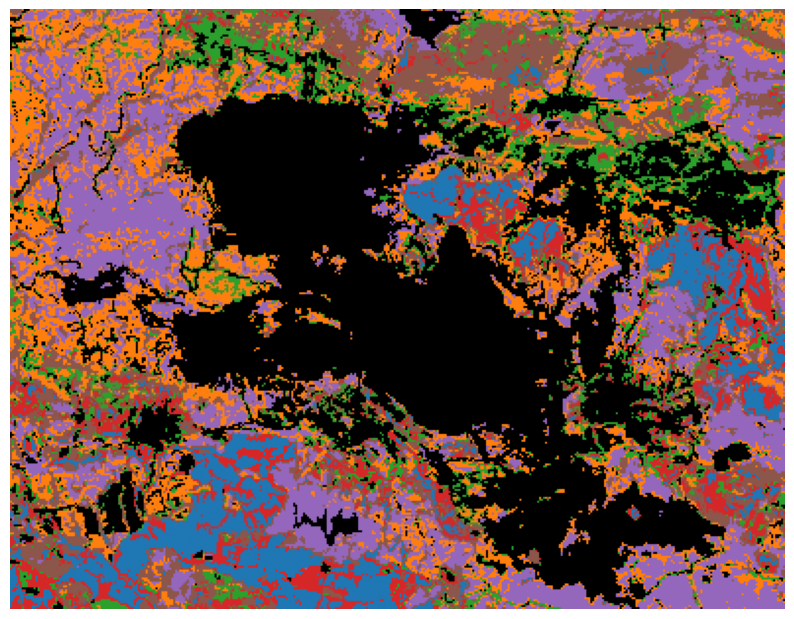

In [16]:
display_clusters(veg_mask_2d, labels_veg, optimal_k_veg)

<div id="22"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.2 Soil

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the soil.

In [17]:
soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = soil_pixels

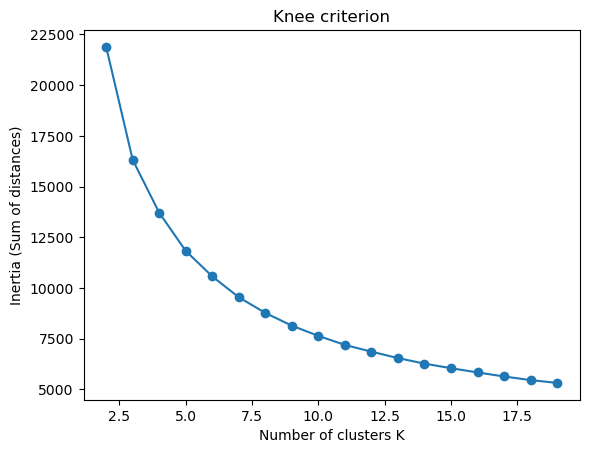

optimal value: k = 7


In [18]:
optimal_k_soil = compute_optimal_k(soil_pixels)

<div style="background-color: #f6bcb2; border-left: 5px solid #ff0000; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: 2d3436;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We decide to not use the optimal k for soil due to external knowledge, using k = 15 instead. 

In [19]:
optimal_k_soil = 15

Silhouette (sampled) for k = 15 : 0.223


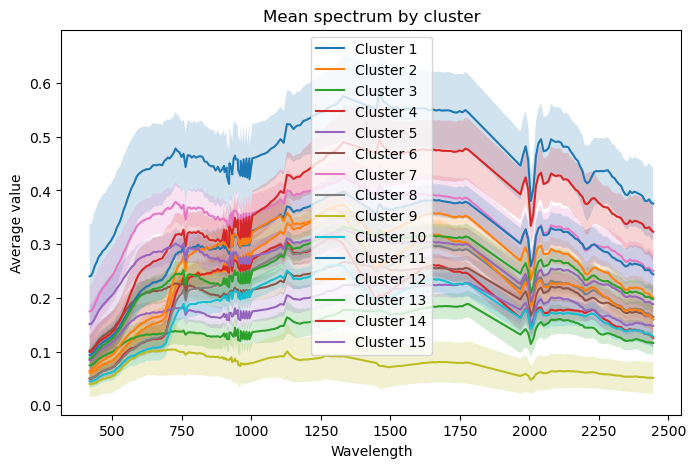

In [20]:
labels_soil = KMeans_mean_spectra(soil_pixels, soil_mask_1d, optimal_k_soil, l, wavelengths)

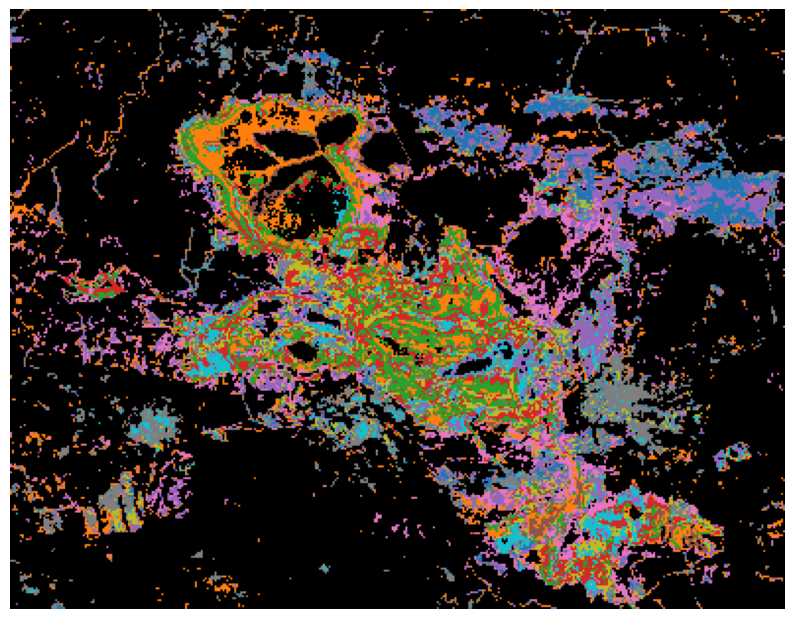

In [21]:
display_clusters(soil_mask_2d, labels_soil, optimal_k_soil)

<div id="23"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.3 Other

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the rest.

In [22]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = other_pixels

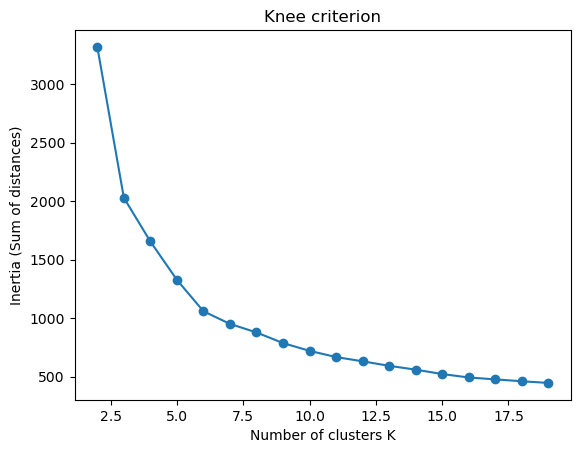

optimal value: k = 6


In [23]:
optimal_k_other = compute_optimal_k(other_pixels)

Silhouette (sampled) for k = 6 : 0.507


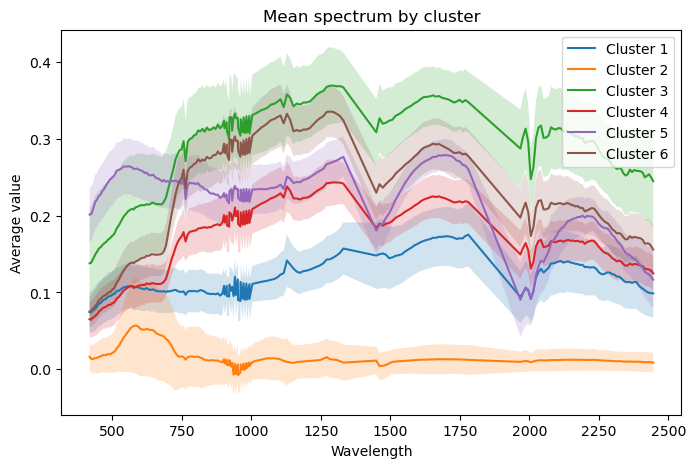

In [24]:
labels_other = KMeans_mean_spectra(other_pixels, other_mask_1d, optimal_k_other, l, wavelengths)

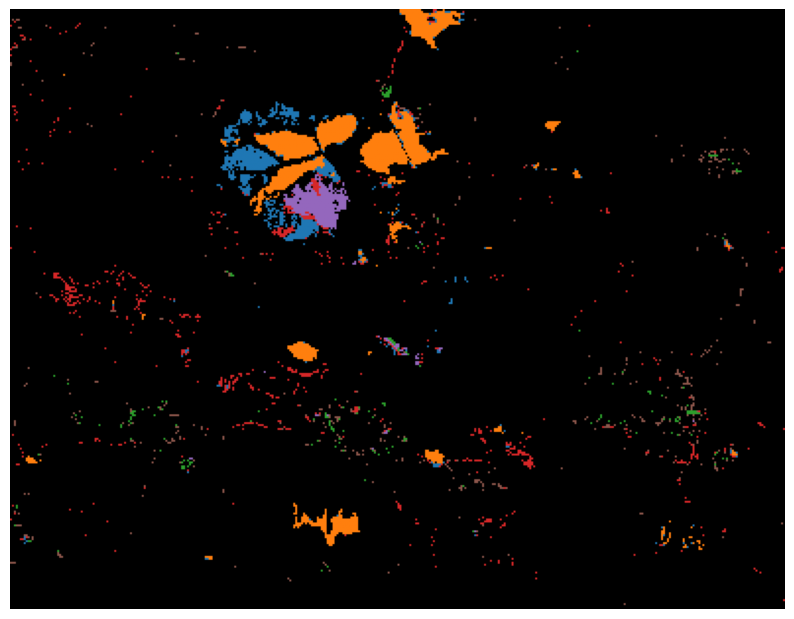

In [25]:
display_clusters(other_mask_2d, labels_other, optimal_k_other)

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Pixel-by-Pixel AutoEncoder with K-Means on latent-space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We first try an AutoEncoder which takes separately each pixel and gives a latent representation. We then apply the K-means algorithm on these representations with the values of "optimal K" obtained precedently.

In [27]:
class PbPAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Hyperparamètres
        self.latent_dim = latent_dim

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.Dropout(dropout_rate), # Régularisation
            
            # 2. Deuxième couche : Compression intermédiaire
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(True),
            
            # 3. Troisième couche (Couche latente)
            nn.Linear(128, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            # 1. Premiére couche : Décompression intermédiaire
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            
            # 2. Deuxième couche : Décompression avancée
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            
            # 3. Dernière couche : Reconstruction de l'entrée
            nn.Linear(256, in_dim),
            #nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [28]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [29]:
def train_PbP_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, max_samples = 10000):

    BANDS = l                    # nb de bandes spectrales
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=1024, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=1024, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = PbPAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for x, in loader:
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    model.eval()

    latent_vectors = []
    with torch.no_grad():
        for (x,) in loader_ordered:
            x = x.to(DEVICE)
            _, z = model(x)
            latent_vectors.append(z.cpu().numpy())
            
    latent_vectors = np.concatenate(latent_vectors, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    kmeans = KMeans(n_clusters, n_init=50, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if X_scaled.shape[0] > max_samples:
        idx = np.random.choice(X_scaled.shape[0], max_samples, replace=False)
        X_sample = X_scaled[idx]
        labels_sample = labels_1d[idx]
    else:
        X_sample = X_scaled
        labels_sample = labels_1d

    # Silhouette "Latente" (Espace du modèle) -> Séparabilité vue par le réseau
    sil_score = silhouette_score(X_sample, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels_1d

In [30]:
def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return colors.ListedColormap(colors)

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Vegetation

In [32]:
LATENT_DIM = 16
N_EPOCHS = 25

labels_1d_veg = train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, veg_pixels, optimal_k_veg)

Epoch 1/25   Loss = 0.010049
Epoch 2/25   Loss = 0.002079
Epoch 3/25   Loss = 0.001194
Epoch 4/25   Loss = 0.000351
Epoch 5/25   Loss = 0.000193
Epoch 6/25   Loss = 0.000165
Epoch 7/25   Loss = 0.000148
Epoch 8/25   Loss = 0.000135
Epoch 9/25   Loss = 0.000138
Epoch 10/25   Loss = 0.000142
Epoch 11/25   Loss = 0.000120
Epoch 12/25   Loss = 0.000140
Epoch 13/25   Loss = 0.000118
Epoch 14/25   Loss = 0.000126
Epoch 15/25   Loss = 0.000120
Epoch 16/25   Loss = 0.000116
Epoch 17/25   Loss = 0.000116
Epoch 18/25   Loss = 0.000120
Epoch 19/25   Loss = 0.000077
Epoch 20/25   Loss = 0.000084
Epoch 21/25   Loss = 0.000071
Epoch 22/25   Loss = 0.000082
Epoch 23/25   Loss = 0.000061
Epoch 24/25   Loss = 0.000081
Epoch 25/25   Loss = 0.000055
Silhouette (échantillon) pour k = 6 : 0.270


<div id="32"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.2 Soil

In [33]:
train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, soil_pixels, optimal_k_soil)

Epoch 1/25   Loss = 0.020653
Epoch 2/25   Loss = 0.004324
Epoch 3/25   Loss = 0.004087
Epoch 4/25   Loss = 0.002979
Epoch 5/25   Loss = 0.001366
Epoch 6/25   Loss = 0.000822
Epoch 7/25   Loss = 0.000618
Epoch 8/25   Loss = 0.000450
Epoch 9/25   Loss = 0.000310
Epoch 10/25   Loss = 0.000270
Epoch 11/25   Loss = 0.000300
Epoch 12/25   Loss = 0.000262
Epoch 13/25   Loss = 0.000251
Epoch 14/25   Loss = 0.000233
Epoch 15/25   Loss = 0.000275
Epoch 16/25   Loss = 0.000284
Epoch 17/25   Loss = 0.000216
Epoch 18/25   Loss = 0.000204
Epoch 19/25   Loss = 0.000210
Epoch 20/25   Loss = 0.000234
Epoch 21/25   Loss = 0.000198
Epoch 22/25   Loss = 0.000173
Epoch 23/25   Loss = 0.000206
Epoch 24/25   Loss = 0.000195
Epoch 25/25   Loss = 0.000137
Silhouette (échantillon) pour k = 15 : 0.203


array([4, 8, 4, ..., 9, 9, 4], shape=(40789,), dtype=int32)

<div id="33"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.3 Other

In [34]:
train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, other_pixels, optimal_k_other)

Epoch 1/25   Loss = 0.074418
Epoch 2/25   Loss = 0.020868
Epoch 3/25   Loss = 0.013231
Epoch 4/25   Loss = 0.008417
Epoch 5/25   Loss = 0.005771
Epoch 6/25   Loss = 0.003932
Epoch 7/25   Loss = 0.002844
Epoch 8/25   Loss = 0.002350
Epoch 9/25   Loss = 0.002051
Epoch 10/25   Loss = 0.001801
Epoch 11/25   Loss = 0.001693
Epoch 12/25   Loss = 0.001571
Epoch 13/25   Loss = 0.001530
Epoch 14/25   Loss = 0.001424
Epoch 15/25   Loss = 0.001323
Epoch 16/25   Loss = 0.001289
Epoch 17/25   Loss = 0.001194
Epoch 18/25   Loss = 0.001154
Epoch 19/25   Loss = 0.001107
Epoch 20/25   Loss = 0.000985
Epoch 21/25   Loss = 0.000919
Epoch 22/25   Loss = 0.000828
Epoch 23/25   Loss = 0.000766
Epoch 24/25   Loss = 0.000706
Epoch 25/25   Loss = 0.000653
Silhouette (échantillon) pour k = 6 : 0.464


array([0, 2, 2, ..., 4, 3, 4], shape=(5407,), dtype=int32)

<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    4. 2D Convolutional AutoEncoder with K-Means on latent space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
As our non-Convolutional AE provides poor results, we will now focus on Convolutional Autoencoders. We apply the K-means algorithm on the latent representation of patches (16*16 pixels for instance). To "propagate" the classification information, there are different options. 

In [46]:
LATENT_DIM = 64
EPOCHS = 20
PATCH_SIZE = 5
STRIDE = 3
BATCH_SIZE = 256
VEG_THRESHOLD = 0.8

In [47]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels, latent_dim=LATENT_DIM):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        self.latent_dim = latent_dim

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=0),
            nn.GroupNorm(8, 64), 
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=1, padding=0),          # H/8
            nn.ReLU(True)
        )
        
        self.fc_enc = nn.Linear(128, self.latent_dim)  # on initialisera dynamiquement au premier forward
        self.fc_dec = nn.Linear(self.latent_dim, 128)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=0),
            nn.GroupNorm(8,64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, in_channels, 3, stride=1, padding=0),  # H*2
            #nn.Sigmoid() On veut pouvoir reconstruire des valeurs négatives : standard scaling
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        z_flat = z.view(z.size(0), -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(z_dec.size(0), 128, 1, 1)
        x_recon = self.decoder_conv(z_dec)

        return x_recon, z_latent
    
    def encode(self, x):
        z = self.encoder_conv(x)
        z_flat = z.view(z.size(0), -1)
        z_latent = self.fc_enc(z_flat)
        return z_latent

In [48]:
def fill_invalid_pixels_with_mean(x_batch, mask_batch):
    """
    x_batch: (B, C, H, W)
    mask_batch: (B, H, W) avec 0 / 1
    """

    mask = mask_batch.unsqueeze(1)  # (B,1,H,W)

    # nombre de pixels valides par patch
    valid_count = mask.sum(dim=(2, 3), keepdim=True).clamp(min=1)

    # moyenne par canal et par patch
    mean_vals = (x_batch * mask).sum(dim=(2, 3), keepdim=True) / valid_count

    # remplacement
    x_filled = x_batch * mask + mean_vals * (1 - mask)

    return x_filled

In [49]:
def generate_valid_patches(img_tensor, mask_tensor, patch_size, stride, batch_size=BATCH_SIZE, min_valid_ratio=VEG_THRESHOLD):
    """
    Génère des batches d'apprentissage où chaque patch a au moins min_valid_ratio de pixels valides
    """
    _, H, W = img_tensor.shape
    # 1️⃣ Lister toutes les positions possibles
    positions = [(i,j) for i in range(0, H - patch_size + 1, stride) for j in range(0, W - patch_size + 1, stride)]
    random.shuffle(positions)
    patches = []

    for i, j in positions :
        patch = img_tensor[:, i:i+patch_size, j:j+patch_size]
        mask_patch = mask_tensor[i:i+patch_size, j:j+patch_size]

        valid_ratio = mask_patch.sum() / (patch_size * patch_size)
        if valid_ratio < min_valid_ratio:
            continue  # rejet du patch

        # Remplacement des pixels invalides par la moyenne locale
        mask_patch_exp = mask_patch.unsqueeze(0)  # (1,H,W)
        valid_count = mask_patch_exp.sum(dim=(1,2), keepdim=True).clamp(min=1)
        mean_vals = (patch * mask_patch_exp).sum(dim=(1,2), keepdim=True) / valid_count
        patch_filled = patch * mask_patch_exp + mean_vals * (1 - mask_patch_exp)

        patches.append(patch_filled.unsqueeze(0))

        if len(patches) == batch_size:
            yield torch.cat(patches, dim=0)
            patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)

In [50]:
def generate_patches_centered(img_tensor, patch_size, sampled_positions, batch_size):
    """
    Génère des patches centrés sur les pixels de référence (i,j)
    """
    patches = []
    half = patch_size // 2
    C, H, W = img_tensor.shape

    for i,j in sampled_positions:
        i_start = i - half
        i_end   = i + half + 1
        j_start = j - half
        j_end   = j + half + 1

        # Clip pour rester dans l'image
        i_start_clip = max(0, i_start)
        i_end_clip   = min(H, i_end)
        j_start_clip = max(0, j_start)
        j_end_clip   = min(W, j_end)

        patch = img_tensor[:, i_start_clip:i_end_clip, j_start_clip:j_end_clip].unsqueeze(0)

        # Padding si nécessaire
        pad_top    = i_start_clip - i_start
        pad_bottom = i_end - i_end_clip
        pad_left   = j_start_clip - j_start
        pad_right  = j_end - j_end_clip

        patch = F.pad(patch, (pad_left, pad_right, pad_top, pad_bottom))
        patches.append(patch)

        if len(patches) == batch_size:
            yield torch.cat(patches, dim=0)
            patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)


def train_Conv2D_autoencoder(EPOCHS, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_complete, mask_2d, MAX_BATCHES_PER_EPOCH):

    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilization du device : {DEVICE}")

    # --- Initialisation du Modèle ---
    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    img_tensor = torch.Tensor(img_scaled_complete.T.reshape(l,m,n))
    mask_tensor = torch.Tensor(mask_2d)

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        accepted_batches = 0

        patch_gen = generate_valid_patches(
            img_tensor, mask_tensor,
            PATCH_SIZE, STRIDE, BATCH_SIZE, VEG_THRESHOLD
        )

        for batch in patch_gen:
            
            batch = batch.to(DEVICE)

            optimizer.zero_grad()
            out, _ = model(batch)
            loss = criterion(out, batch)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            accepted_batches += 1

            if accepted_batches >= MAX_BATCHES_PER_EPOCH:
                break

        print(f"Epoch {ep+1}/{EPOCHS} | Batches: {accepted_batches} | Loss: {loss_sum/max(1, accepted_batches):.6f}")

        torch.cuda.empty_cache()

    # --------------------------
    # PHASE 2 : EXTRACTION DES LATENTS
    # --------------------------
    model.eval()
    model.cpu()

    _, H, W = img_tensor.shape


    # 1️⃣ Lister tous les pixels valides pour le patch top-left
    valid_positions = [
        (i,j)
        for i in range(H - PATCH_SIZE + 1)
        for j in range(W - PATCH_SIZE + 1)
        if mask_tensor[i,j] == 1
    ]

    # 2️⃣ Construire patches centrés batch par batch
    all_latents = []
    INFERENCE_BATCH_SIZE = 1024
    for patch_batch in generate_patches_centered(img_tensor, PATCH_SIZE, valid_positions, batch_size=INFERENCE_BATCH_SIZE):
        with torch.no_grad():
            z = model.encode(patch_batch)  # (B, latent_dim)
        all_latents.append(z.cpu().numpy())
    latents = np.concatenate(all_latents, axis=0)

    return latents, valid_positions

<div id="41"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.1 Vegetation

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
A simple option is to assume the cluster assigned to the patch is in reality the cluster assigned to the pixel at the center of this patch.

In [51]:
def KM_Silhouette(img_2d, positions, latent_vectors, n_clusters, max_samples):
    kmeans = KMeans(n_clusters, n_init=100, random_state=0)
    scaler = StandardScaler()
    latent_norms = scaler.fit_transform(latent_vectors)
    labels = kmeans.fit_predict(latent_norms)
    X_phys_aligned = []

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if latent_vectors.shape[0] > max_samples:
        idx = np.random.choice(latent_vectors.shape[0], max_samples, replace=False)
        labels_sample = labels[idx]
    else:
        labels_sample = labels

    print("Extraction des pixels physiques alignés...")
    for id in idx:
        # C'est ICI que se joue l'alignement
        r, c = positions[id] 
        
        # On récupère la valeur du pixel à cette coordonnée précise
        pixel_val = img_2d[r, c, :] 
        X_phys_aligned.append(pixel_val)

    X_phys_aligned = np.array(X_phys_aligned)

    sil_score = silhouette_score(X_phys_aligned, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels

In [52]:
latent_vectors_veg, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_veg_complete, veg_mask_2d, MAX_BATCHES_PER_EPOCH=300
)


Utilization du device : cuda
Epoch 1/20 | Batches: 29 | Loss: 0.009211
Epoch 2/20 | Batches: 29 | Loss: 0.002172
Epoch 3/20 | Batches: 29 | Loss: 0.002002
Epoch 4/20 | Batches: 29 | Loss: 0.001735
Epoch 5/20 | Batches: 29 | Loss: 0.001265
Epoch 6/20 | Batches: 29 | Loss: 0.001191
Epoch 7/20 | Batches: 29 | Loss: 0.001028
Epoch 8/20 | Batches: 29 | Loss: 0.001012
Epoch 9/20 | Batches: 29 | Loss: 0.000956
Epoch 10/20 | Batches: 29 | Loss: 0.000855
Epoch 11/20 | Batches: 29 | Loss: 0.000774
Epoch 12/20 | Batches: 29 | Loss: 0.000718
Epoch 13/20 | Batches: 29 | Loss: 0.000719
Epoch 14/20 | Batches: 29 | Loss: 0.000789
Epoch 15/20 | Batches: 29 | Loss: 0.000652
Epoch 16/20 | Batches: 29 | Loss: 0.000612
Epoch 17/20 | Batches: 29 | Loss: 0.000591
Epoch 18/20 | Batches: 29 | Loss: 0.000612
Epoch 19/20 | Batches: 29 | Loss: 0.000556
Epoch 20/20 | Batches: 29 | Loss: 0.000546


In [53]:
labels_veg = KM_Silhouette(img_scaled_veg_complete.reshape(m,n,l), positions, latent_vectors_veg, optimal_k_veg, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 6 : 0.068


In [54]:
from collections import Counter
cluster_counts = Counter(labels_veg)
print(cluster_counts)

Counter({np.int32(5): 16030, np.int32(3): 15981, np.int32(2): 13895, np.int32(1): 13534, np.int32(4): 12582, np.int32(0): 4439})


<div id="42"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.2 Soil

In [71]:
latent_vectors_soil = train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled_soil, optimal_k_soil, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_soil_complete, soil_mask_2d, MAX_SAMPLES)

Utilization du device : cuda
Nombre de patchs valides : 18476
Epoch 1/5  Batch 74/73  Loss: 0.877551
Epoch 1/5   Moyenne Loss = 0.968989
Epoch 2/5  Batch 74/73  Loss: 0.796109
Epoch 2/5   Moyenne Loss = 0.803635
Epoch 3/5  Batch 74/73  Loss: 0.652647
Epoch 3/5   Moyenne Loss = 0.749745
Epoch 4/5  Batch 74/73  Loss: 0.830428
Epoch 4/5   Moyenne Loss = 0.731369
Epoch 5/5  Batch 74/73  Loss: 0.853352
Epoch 5/5   Moyenne Loss = 0.725432


In [72]:
labels_soil = KM_Silhouette(latent_vectors_soil, optimal_k_soil)

Silhouette (échantillon) pour k = 30 : 0.299
Calinski-Harabasz pour k = 30 : 1015.87


<div id="43"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.3 Other

In [74]:
latent_vectors_other = train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled_other, optimal_k_other, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_other_complete, other_mask_2d, MAX_SAMPLES)

Utilization du device : cuda
Nombre de patchs valides : 447
Epoch 1/5  Batch 3/2  Loss: 1.495754
Epoch 1/5   Moyenne Loss = 1.538028
Epoch 2/5  Batch 3/2  Loss: 1.358628
Epoch 2/5   Moyenne Loss = 1.458864
Epoch 3/5  Batch 3/2  Loss: 0.986373
Epoch 3/5   Moyenne Loss = 1.093725
Epoch 4/5  Batch 3/2  Loss: 0.923839
Epoch 4/5   Moyenne Loss = 0.933698
Epoch 5/5  Batch 3/2  Loss: 0.934243
Epoch 5/5   Moyenne Loss = 0.942122


In [75]:
labels_other = KM_Silhouette(latent_vectors_other, optimal_k_other)

Silhouette (échantillon) pour k = 6 : 0.803
Calinski-Harabasz pour k = 6 : 3075.22


Nombre de clusters pour la végétation avec CAH

In [10]:
N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]
X_sample_original = veg_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

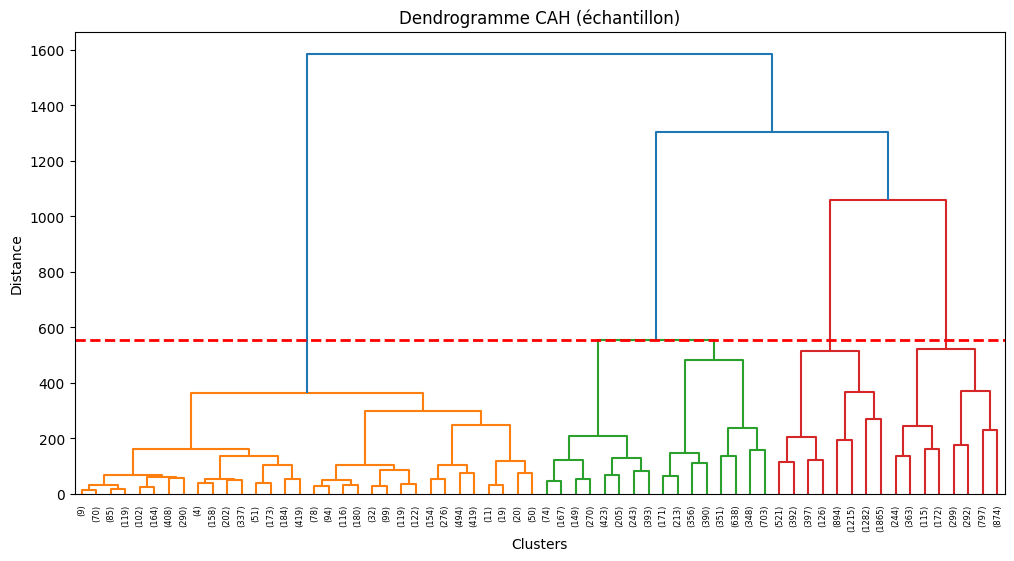

In [11]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

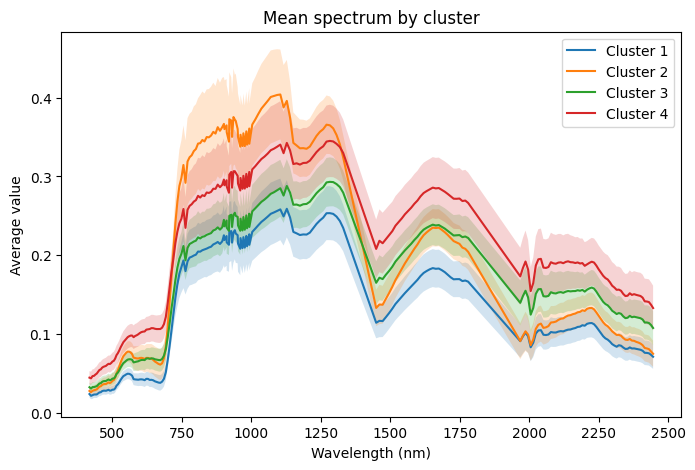

In [14]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Clusters can be associated to different kinds of vegetation which is more or less sane depending on the mean spectrum : a lower reflectance means that the vegetation is less dense/sane while a higher reflectance indicates luxurious vegetation.

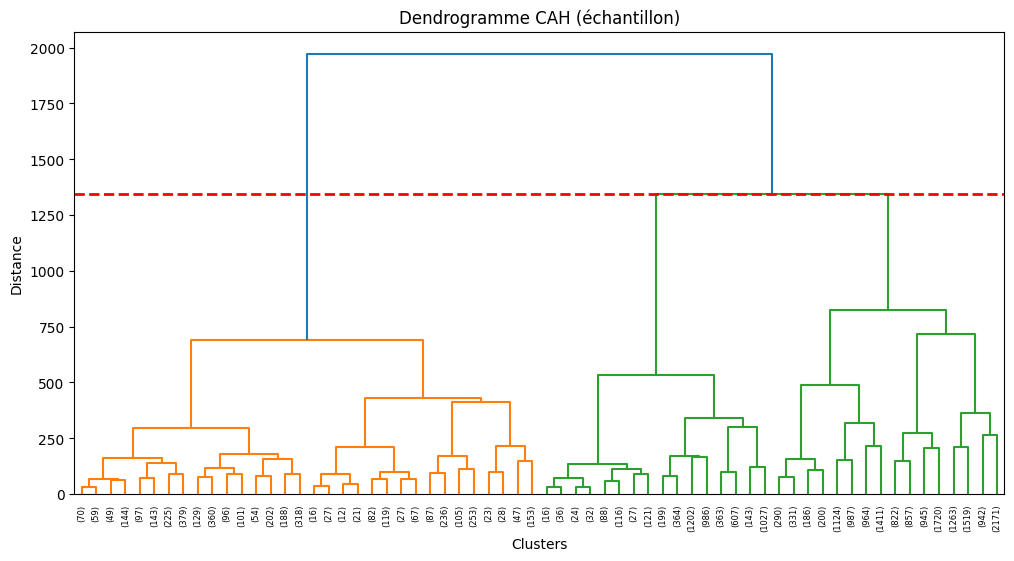

In [16]:
N = 25000
idx = np.random.choice(len(X_scaled_soil), N, replace=False)
X_sample = X_scaled_soil[idx]
X_sample_original = soil_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


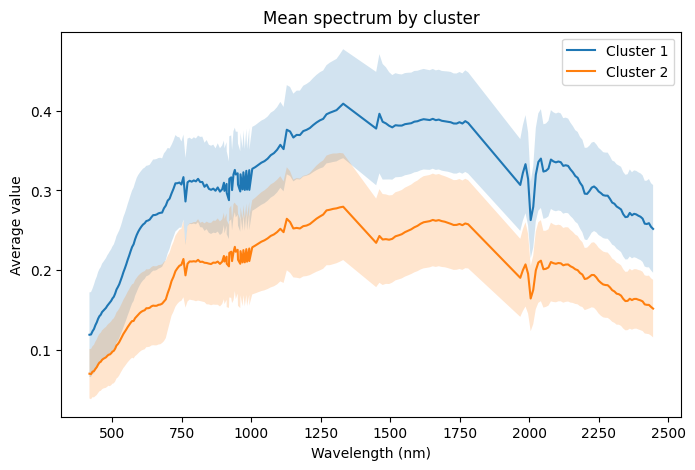

In [17]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters for the soil. The mean spectrum shows that both clusters have similar shapes, but that cluster one has lower reflectance, which could be due to the presence of water. Thus, we can suggest that cluster one corresponds to wet soils (agricultural soils, loamy soils...) and cluster two to drier soil areas.

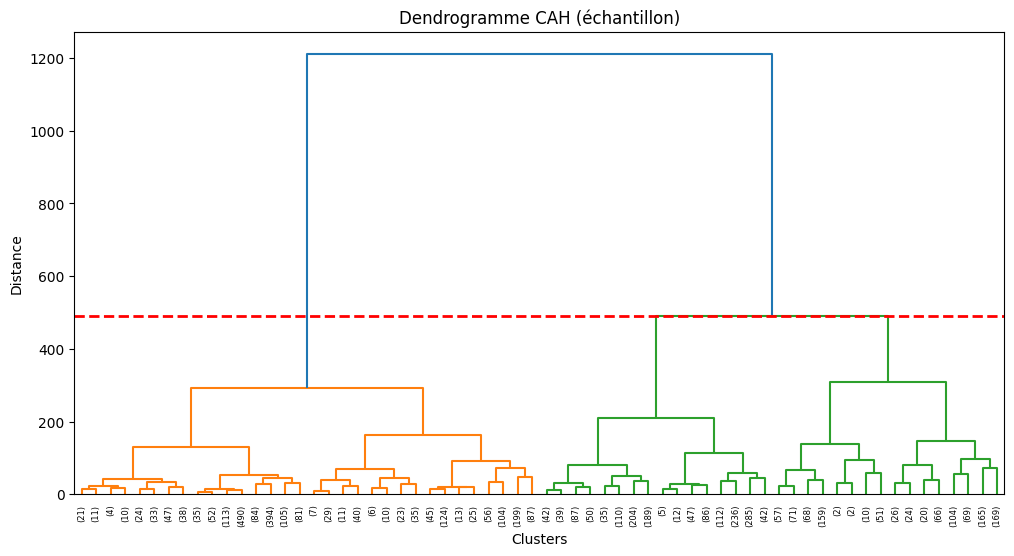

In [23]:
N = 5000
idx = np.random.choice(len(X_scaled_other), N, replace=False)
X_sample = X_scaled_other[idx]
X_sample_original = other_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

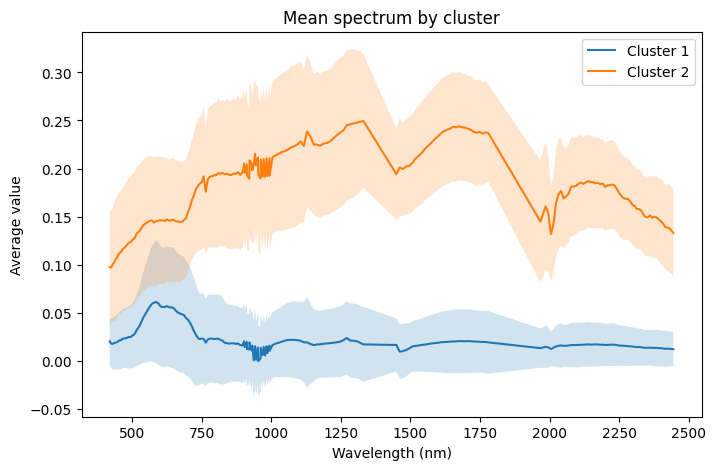

In [24]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters for the remaining pixels. Cluster one, with very low reflectance, has a shape that is characteristic of water areas (shallow water). Cluster two has a shape that recalls the spectrum of concrete or similar materials, which could be associated to more urban areas.